In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Load and Inspect the Data

In [7]:
df = pd.read_csv(r'C:\Users\faraz\Downloads\global_ecommerce_sales.csv')

In [13]:
print(df.head())

    Order_ID Order_Date   Customer_Name Customer_Segment        Country  \
0  ORD-11121 2023-01-02    Karen Suzuki        Corporate  United States   
1  ORD-11244 2023-01-02  John Johansson        Corporate          Spain   
2  ORD-10325 2023-01-03  Jessica Garcia         Consumer         Mexico   
3  ORD-10467 2023-01-03    Clara Taylor        Corporate          Italy   
4  ORD-11454 2023-01-05    Felix Thomas         Consumer          Italy   

          Region Product_Category                   Product_Name  Quantity  \
0  North America       Technology  Wireless Bluetooth Headphones         3   
1         Europe       Technology     Mechanical Gaming Keyboard         4   
2  North America  Office Supplies     Binder Clips Assorted 48pc         2   
3         Europe       Technology                Webcam HD 1080p         2   
4         Europe        Furniture        Standing Desk Converter         4   

   Unit_Price  Discount_Percent  Total_Sales  Shipping_Cost  Profit  \
0       9

In [14]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [15]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2000 non-null   object        
 1   Order_Date        2000 non-null   datetime64[ns]
 2   Customer_Name     2000 non-null   object        
 3   Customer_Segment  2000 non-null   object        
 4   Country           2000 non-null   object        
 5   Region            2000 non-null   object        
 6   Product_Category  2000 non-null   object        
 7   Product_Name      2000 non-null   object        
 8   Quantity          2000 non-null   int64         
 9   Unit_Price        2000 non-null   float64       
 10  Discount_Percent  2000 non-null   int64         
 11  Total_Sales       2000 non-null   float64       
 12  Shipping_Cost     2000 non-null   float64       
 13  Profit            2000 non-null   float64       
 14  Payment_Method    2000 n

In [16]:
total_sales = round(df['Total_Sales'].sum())
total_shipping = round(df['Shipping_Cost'].sum())
total_profit = round(df['Profit'].sum())
total_cost = round(total_sales - total_profit)

In [21]:
print("Total Sales Amount: $",total_sales)
print("Total Shipping Cost: $", total_shipping)
print("Total Profit: $", total_profit)
print("Total Cost Amount: $", total_cost)

Total Sales Amount: $ 484559
Total Shipping Cost: $ 25804
Total Profit: $ 158872
Total Cost Amount: $ 325687


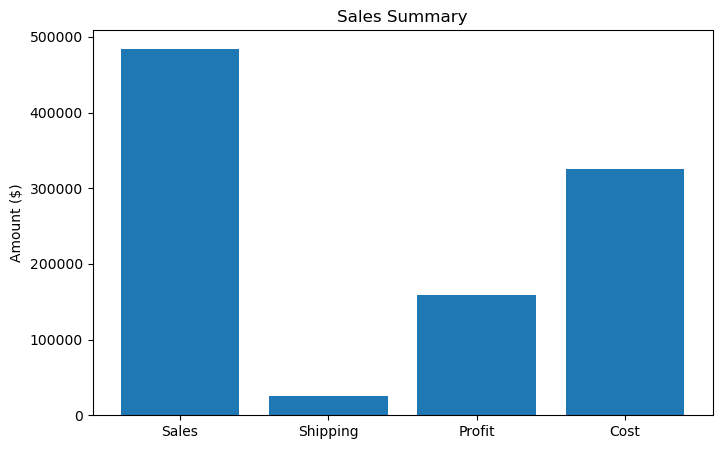

In [56]:
metrics = ['Sales', 'Shipping', 'Profit', 'Cost']
values = [total_sales, total_shipping, total_profit, total_cost]

plt.figure(figsize=(8, 5) )
plt.bar(metrics, values)

plt.title('Sales Summary')
plt.ylabel('Amount ($)')
plt.show()

---------------------------------------

*The business achieved an impressive milestone this period by generating nearly 485,000 in total sales. While fulfilling these orders required a significant cost investment of over 320,000, efficient logistics kept shipping expenses down to a bare minimum. As a result, the company successfully locked in a solid profit of around $160,000, proving that their current business strategy is highly lucrative.*

-------------------------------

### Calculate RFM Metrics

In [83]:
snapshot_date = df['Order_Date'].max() + pd.Timedelta(days=1)

In [84]:
rfm = df.groupby('Customer_Name').agg({
    'Order_Date': lambda x: (snapshot_date - x.max()).days, 
    'Order_ID': 'count',                                    
    'Total_Sales': 'sum'                                   
})

In [85]:
rfm.rename(columns={'Order_Date': 'Recency', 'Order_ID': 'Frequency', 'Total_Sales': 'Monetary'}, inplace=True)
print(rfm.head(10))

                 Recency  Frequency  Monetary
Customer_Name                                
Ahmed Ali            384          1    509.12
Ahmed Anderson       494          1    133.68
Ahmed Clark          636          2     94.28
Ahmed Dubois          23          3    105.73
Ahmed Garcia         923          2   1769.48
Ahmed Harris        1030          1    598.14
Ahmed Hassan         264          1    162.03
Ahmed Jackson        275          2    247.54
Ahmed Johansson      133          2   1670.10
Ahmed Johnson        383          1     27.50


### Data Standardization

In [86]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [87]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)

In [88]:
print (rfm_scaled_df)

                 Recency  Frequency  Monetary
Customer_Name                                
Ahmed Ali      -0.312617  -0.536164  0.426506
Ahmed Anderson  0.037446  -0.536164 -0.402138
Ahmed Clark     0.489345   1.228804 -0.489099
Ahmed Dubois   -1.461459   2.993773 -0.463827
Ahmed Garcia    1.402691   1.228804  3.208282
...                  ...        ...       ...
Zara Thomas    -0.102579  -0.536164 -0.486340
Zara Wang      -1.270516  -0.536164 -0.641192
Zara Weber     -0.318982  -0.536164 -0.592437
Zara White      0.365232   1.228804 -0.488569
Zara Williams  -1.225962   1.228804  1.859771

[1534 rows x 3 columns]


### The Elbow Method

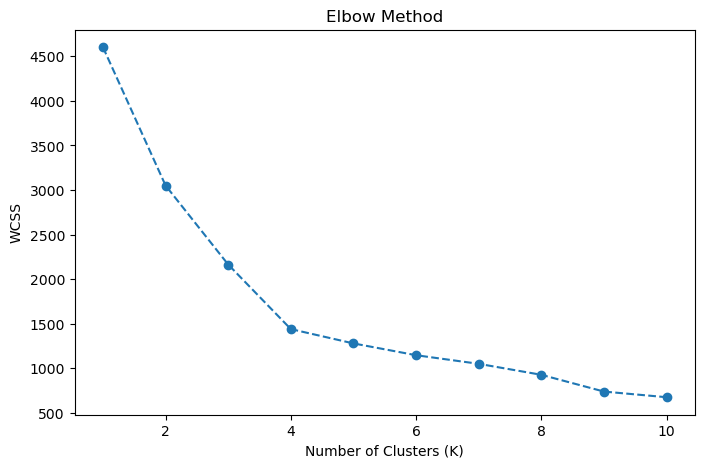

In [89]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

-------------------------------------

*Elbow Method to determine the perfect way to segment their massive customer base. As they tested different groupings, they watched the WCSS drop drastically until the number of clusters reached 4. After this point, the curve flattened out significantly, showing that adding more groups would only lead to diminishing returns. This distinct "elbow" at K = 4 confidently revealed the optimal choice, giving the team a clear roadmap for their targeted marketing strategy.*

----------------------------------

### Run K-Means & Profile Clusters

In [39]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

In [40]:
cluster_profile = rfm.groupby('Cluster').mean()
print(cluster_profile)

            Recency  Frequency     Monetary
Cluster                                    
0        267.283217   1.000000   180.480367
1        823.149446   1.025830   194.429465
2        305.208211   2.187683   380.790499
3        463.759494   1.594937  1849.294177


### Visualizations

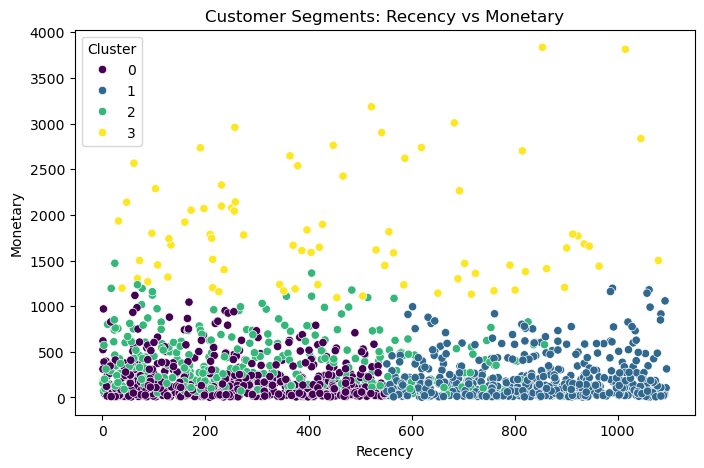

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('Customer Segments: Recency vs Monetary')
plt.show()

----------------------------

*Following the previous analysis, the marketing team mapped out their customer base into four distinct strategic groups. The yellow points (Cluster 3) immediately stood out as their VIP high-spenders, requiring premium loyalty perks to keep them engaged. Meanwhile, the team realized the purple and green clusters represented active, recent shoppers perfect for steady upsell promotions, while the blue cluster signaled long-lost customers who needed an aggressive re-engagement campaign. This clear segmentation successfully transformed a scattered pool of data into a highly targeted action plan for the business.*

--------------------------------

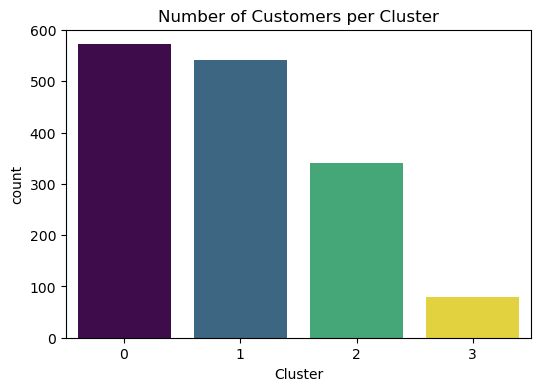

In [43]:
plt.figure(figsize=(6, 4))

sns.countplot(data=rfm, x='Cluster', hue='Cluster', palette='viridis', legend=False)

plt.title('Number of Customers per Cluster')
plt.show()

---------------------------

*To finalize their strategy, the team analyzed the actual size of each segment to allocate their budget effectively. They discovered that the vast majority of their audience sits within Clusters 0 and 1, representing a massive core customer base of over 1,100 individuals who drive steady volume. Meanwhile, the high-spending VIP group in Cluster 3 is the smallest with fewer than 100 exclusive clients, confirming that their most lucrative revenue comes from a highly selective elite tier. Armed with these distribution metrics, the company can now confidently balance broad, cost-effective campaigns with highly personalized perks for their top spenders.*

-------------------------------------------------

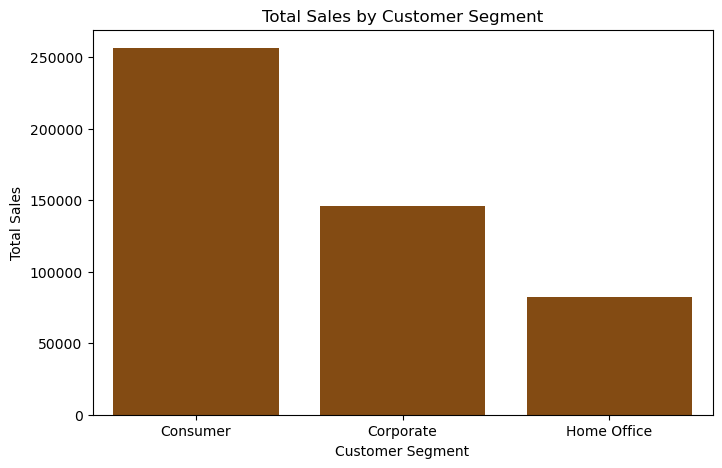

In [75]:
segment_sales = df.groupby('Customer_Segment')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_sales,
    x='Customer_Segment',
    y='Total_Sales',
    color='#964B00'
)

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

---------------------

*Shifting their focus to specific market demographics, the team broke down their revenue into broader traditional categories. The "Consumer" segment emerged as the undisputed powerhouse of the business, bringing in an incredible revenue of over 250,000 on its own. While the "Corporate" clients brought in a healthy 145,000 and "Home Office" shoppers added another $80,000 to the mix, it became entirely clear where the company's true volume lies. Moving forward, the marketing team plans to aggressively scale their consumer-focused products while maintaining stable, steady relations with their corporate partners.*

-------------------------

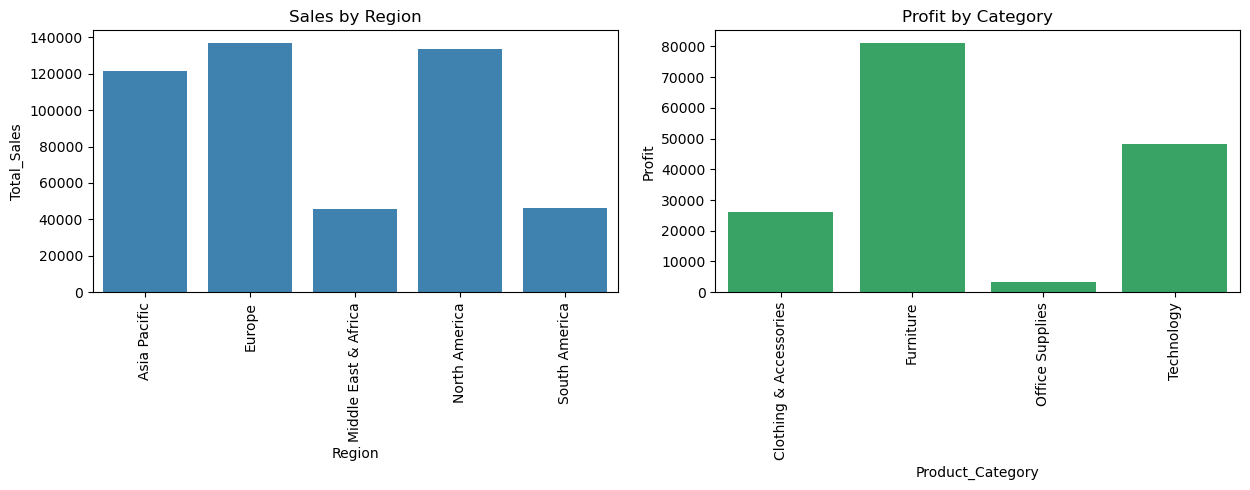

In [82]:
region = df.groupby('Region')['Total_Sales'].sum().reset_index()

category = df.groupby('Product_Category')['Profit'].sum().reset_index()

plt.figure(figsize=(18,5))

# Chart 1
plt.subplot(1,3,2)
sns.barplot(data=region, x='Region', y='Total_Sales', color='#2E86C1')
plt.title('Sales by Region')
plt.xticks(rotation=90)

# Chart 2
plt.subplot(1,3,3)
sns.barplot(data=category, x='Product_Category', y='Profit', color='#28B463')
plt.title('Profit by Category')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

-------------------------

*To pinpoint exactly where their revenue was coming from, the management zoomed into a regional and product-level breakdown. They observed that Europe and North America are their absolute powerhouse markets, both generating dominant sales figures well over 130,000 each. Surprisingly, when looking at product performance, it wasn't tech driving the biggest returns, but Furniture, which single-handedly secured an incredible profit of over $80,000. These insights gave the executives a precise map of their true growth engines, allowing them to double down on what genuinely keeps the business thriving.*

------------------------------------

* # Customer Segmentation Analysis (RFM-Based Strategy)

## ● Segment 1: "The Champions" (VIPs)

### ● Profile:
● Low Recency (recent buyers)  
● High Frequency (frequent buyers)  
● High Monetary (high spenders)  
● High Profitability  

### ● Behavioral Insight:
● These customers have very low discount affinity  
● They purchase based on quality and trust  

### ● Marketing Strategy:
● No discounts needed (protect profit margins)  
● VIP / Loyalty Program (Gold / Platinum tier)  
● Early access to new products (48-hour exclusive launch)  
● Premium customer support / priority service  

---

## ● Segment 2: "High-Volume Bargain Hunters" (Low Margin Customers)

### ● Profile:
● High Frequency  
● High Monetary  
● Low / Negative Profitability  
● High discount dependency  

### ● Behavioral Insight:
● These customers mostly depend on discounts and deals  

### ● Marketing Strategy:
● Bundle offers (mix of high and low margin products)  
● Minimum Order Value for discounts (e.g., $100+)  
● Free shipping restrictions (protect profit margins)  
● Cross-selling high-margin products  

---

## ● Segment 3: "Can't Lose Them" (Churn Risk VIPs)

### ● Profile:
● High Recency gap (inactive customers)  
● High historical value  
● High profit contribution  

### ● Behavioral Insight:
● These are previously loyal customers who are now inactive  

### ● Marketing Strategy:
● Win-back campaigns (personalized messages)  
● Discount offers (e.g., 25% comeback coupon)  
● Feedback surveys with reward incentives  
● Payment-based targeted offers  

---

## ● Segment 4: "New & Uncertain Prospects"

### ● Profile:
● Low Frequency  
● Low Monetary  
● New customers  

### ● Behavioral Insight:
● Their behavior is not yet established  

### ● Marketing Strategy:
● Welcome / onboarding email sequence  
● 2nd purchase trigger (within 7 days)  
● Social proof (reviews & testimonials)  
● Focus on converting first purchase into second purchase*

## ------------------------- Customer Segmentation Summary Table------------------------------
| Cluster     | Segment Type         | Key Metric Driver                     | Marketing Channel        | Core Strategy              |
|-------------|---------------------|--------------------------------------|--------------------------|----------------------------|
| Cluster 0   | Champions           | High Profit / High Frequency        | Email / WhatsApp         | Loyalty & Exclusivity      |
| Cluster 1   | Bargain Hunters     | High Discount / Low Profit          | Push Notifications       | Margin Protection & Bundling |
| Cluster 2   | Churn Risk VIPs     | High Past Value, Now Inactive       | SMS / Retargeting Ads    | Win-back Campaign          |
| Cluster 3   | New Customers       | Low Frequency / Low Value           | Email Automation         | Trust Building & 2nd Order |